In [ ]:

from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
 )

['AggregationStrategy', 'Any', 'ArgumentHandler', 'AudioClassificationPipeline', 'AutoConfig', 'AutoFeatureExtractor', 'AutoImageProcessor', 'AutoModel', 'AutoModelForAudioClassification', 'AutoModelForCTC', 'AutoModelForCausalLM', 'AutoModelForDepthEstimation', 'AutoModelForDocumentQuestionAnswering', 'AutoModelForImageClassification', 'AutoModelForImageSegmentation', 'AutoModelForImageTextToText', 'AutoModelForImageToImage', 'AutoModelForKeypointMatching', 'AutoModelForMaskGeneration', 'AutoModelForMaskedLM', 'AutoModelForObjectDetection', 'AutoModelForQuestionAnswering', 'AutoModelForSemanticSegmentation', 'AutoModelForSeq2SeqLM', 'AutoModelForSequenceClassification', 'AutoModelForSpeechSeq2Seq', 'AutoModelForTableQuestionAnswering', 'AutoModelForTextToSpectrogram', 'AutoModelForTextToWaveform', 'AutoModelForTokenClassification', 'AutoModelForVideoClassification', 'AutoModelForVision2Seq', 'AutoModelForVisualQuestionAnswering', 'AutoModelForZeroShotImageClassification', 'AutoModelFo

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [6]:
df = pd.read_csv("..\data\IMDB-Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
X = df["review"]
y = df["sentiment"]

In [8]:
Vectorizer = CountVectorizer(stop_words= "english",max_features = 5000)
model = MultinomialNB()

In [9]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)


In [10]:
X_train_vec = Vectorizer.fit_transform(X_train)
model.fit(X_train_vec,Y_train)
X_test_vec = Vectorizer.transform(X_test)
Y_pred = model.predict(X_test_vec)
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.85      0.85      5000
    positive       0.85      0.84      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



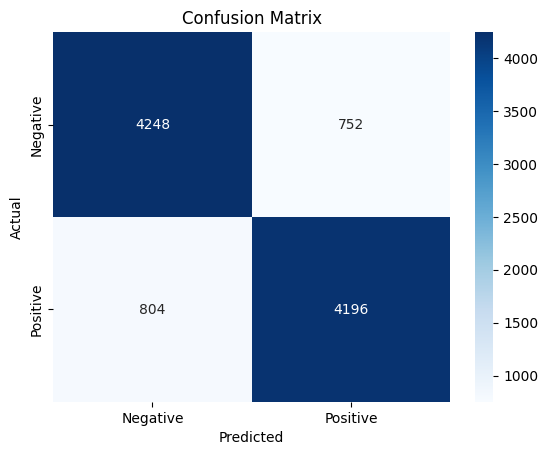

In [ ]:
cm = confusion_matrix(Y_test,Y_pred)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True,fmt = "d",cmap = "ff\7B" \
"
" \
"lues", xticklabels = ["Negative","Positive"], yticklabels = ["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()